In [482]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

In [483]:
df=pd.read_csv('placement.csv')
df 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


<Axes: xlabel='cgpa', ylabel='resume_score'>

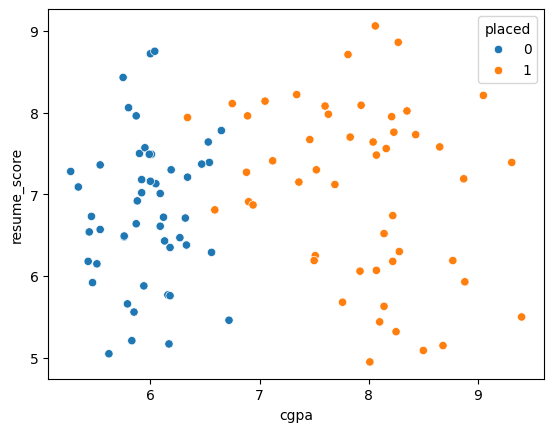

In [484]:
sns.scatterplot(data=df,x='cgpa',y='resume_score',hue='placed')

In [485]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('placed',axis=1),df['placed'],train_size=0.8)

In [486]:
x_train

,cgpa,resume_score
33,8.43,7.73
62,5.75,8.43
76,9.40,5.50
48,5.54,6.57
60,5.87,6.64
...,...,...
24,8.22,6.18
31,5.92,7.02
70,7.12,7.41
1,6.17,5.17


In [487]:
y_test

32    0
79    0
15    1
2     1
40    1
25    1
53    0
90    0
73    0
96    1
51    0
77    0
49    0
43    1
14    1
41    1
63    1
95    0
83    1
80    1
Name: placed, dtype: int64

In [488]:
y_train

33    1
62    0
76    1
48    0
60    0
     ..
24    1
31    0
70    1
1     0
26    0
Name: placed, Length: 80, dtype: int64

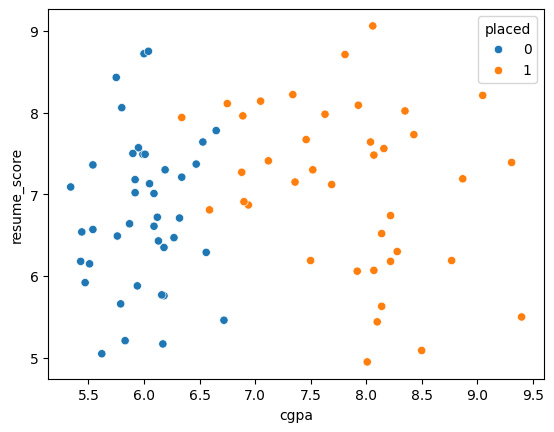

In [489]:
sns.scatterplot(x=x_train['cgpa'],y=x_train['resume_score'],hue=y_train)
plt.savefig('data distribution.png')

In [490]:
model=LinearRegression(n_jobs=-1)
model.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<Axes: >

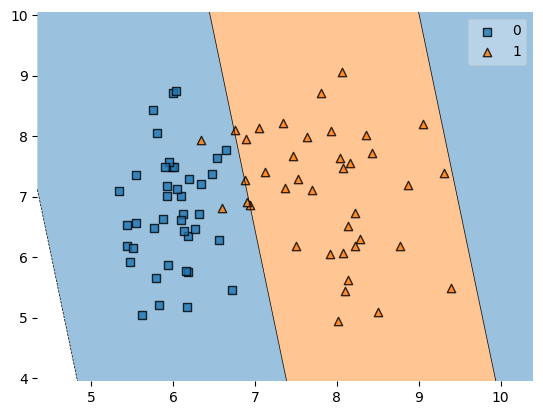

In [491]:
x=np.array(x_train)
y=np.array(y_train)
plot_decision_regions(x,y,model)

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<Axes: >

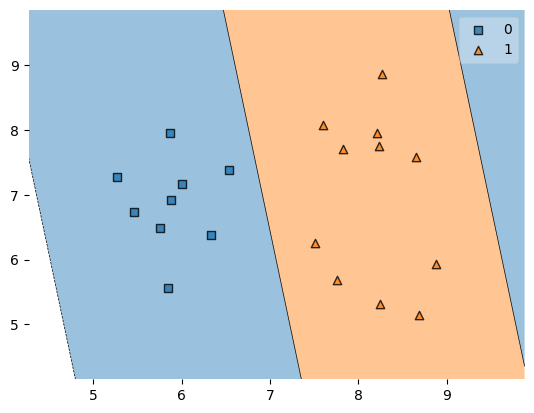

In [492]:
x=np.array(x_test)
y=np.array(y_test)
plot_decision_regions(x,y,model)

In [493]:
df 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


# Perceptron Trick 

# Introducing new column for bias term 

In [494]:
df 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


In [495]:
df['w0']=np.ones(df.shape[0])

In [496]:
df 

,cgpa,resume_score,placed,w0
0,8.14,6.52,1,1.0
1,6.17,5.17,0,1.0
2,8.27,8.86,1,1.0
3,6.88,7.27,1,1.0
4,7.52,7.30,1,1.0
...,...,...,...,...
95,6.33,6.38,0,1.0
96,8.23,7.76,1,1.0
97,6.65,7.78,0,1.0
98,8.14,5.63,1,1.0


In [497]:
# def move_column(df, column_name, new_position):
#     cols = list(df.columns)
#     cols.insert(new_position, cols.pop(cols.index(column_name)))
#     return df[cols]

# df = move_column(df, 'w0', 0)
# df = move_column(df, 'cgpa', 2)

df = df[["w0", "resume_score", "cgpa", "placed"]]


In [498]:
df 

,w0,resume_score,cgpa,placed
0,1.0,6.52,8.14,1
1,1.0,5.17,6.17,0
2,1.0,8.86,8.27,1
3,1.0,7.27,6.88,1
4,1.0,7.30,7.52,1
...,...,...,...,...
95,1.0,6.38,6.33,0
96,1.0,7.76,8.23,1
97,1.0,7.78,6.65,0
98,1.0,5.63,8.14,1


In [499]:
# x_train,x_test,y_train,y_test=train_test_split(df.drop('placed',axis=1),df['placed'],train_size=0.8)

In [500]:
x=df.drop('placed',axis=1).values
x 

array([[1.  , 6.52, 8.14],
       [1.  , 5.17, 6.17],
       [1.  , 8.86, 8.27],
       [1.  , 7.27, 6.88],
       [1.  , 7.3 , 7.52],
       [1.  , 6.19, 8.77],
       [1.  , 7.09, 5.34],
       [1.  , 6.29, 6.56],
       [1.  , 6.71, 6.32],
       [1.  , 7.12, 7.69],
       [1.  , 6.35, 6.18],
       [1.  , 6.54, 5.44],
       [1.  , 7.01, 6.09],
       [1.  , 5.09, 8.5 ],
       [1.  , 6.25, 7.51],
       [1.  , 5.93, 8.88],
       [1.  , 7.64, 8.04],
       [1.  , 8.71, 7.81],
       [1.  , 5.88, 5.94],
       [1.  , 8.11, 6.75],
       [1.  , 8.06, 5.8 ],
       [1.  , 7.64, 6.53],
       [1.  , 5.77, 6.16],
       [1.  , 7.13, 6.05],
       [1.  , 6.18, 8.22],
       [1.  , 5.68, 7.76],
       [1.  , 6.47, 6.27],
       [1.  , 6.15, 5.51],
       [1.  , 7.67, 7.46],
       [1.  , 7.3 , 6.19],
       [1.  , 7.15, 7.36],
       [1.  , 7.02, 5.92],
       [1.  , 7.96, 5.87],
       [1.  , 7.73, 8.43],
       [1.  , 7.19, 8.87],
       [1.  , 7.48, 8.07],
       [1.  , 7.56, 8.16],
 

In [501]:
y=df['placed'].values 
y 

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [502]:
def perceptron(x,y,epochs): 
     weights=np.ones(x.shape[1])
     lr=0.1
     for epoch in range(epochs):
         for i in range(len(x)): 
             y_hat = 1 if np.dot(x[i], weights) > 0 else 0
             weights=weights+(lr*(y[i]-y_hat)*x[i]) 

     return weights 

In [503]:
w0,w1,w2=perceptron(x,y,2000)
print('CGPA weight',w2)
print('resume score weight',w1)
print('bias term  weight',w0)

CGPA weight 11.894000000002336
resume score weight 1.34399999999976
bias term  weight -90.19999999999915


In [504]:
df 

,w0,resume_score,cgpa,placed
0,1.0,6.52,8.14,1
1,1.0,5.17,6.17,0
2,1.0,8.86,8.27,1
3,1.0,7.27,6.88,1
4,1.0,7.30,7.52,1
...,...,...,...,...
95,1.0,6.38,6.33,0
96,1.0,7.76,8.23,1
97,1.0,7.78,6.65,0
98,1.0,5.63,8.14,1


In [505]:
output=w0+6.52*w1+8.14*w2
if output>=0.5: 
    print('Placed')
else: 
    print('Not Placed ')

Placed


In [506]:
m=-(w2/w1) 
c=-(w0/w1)

In [507]:
m 

np.float64(-8.8497023809557)

In [508]:
c 

np.float64(67.11309523810658)

In [509]:
x[:,2]

array([8.14, 6.17, 8.27, 6.88, 7.52, 8.77, 5.34, 6.56, 6.32, 7.69, 6.18,
       5.44, 6.09, 8.5 , 7.51, 8.88, 8.04, 7.81, 5.94, 6.75, 5.8 , 6.53,
       6.16, 6.05, 8.22, 7.76, 6.27, 5.51, 7.46, 6.19, 7.36, 5.92, 5.87,
       8.43, 8.87, 8.07, 8.16, 9.05, 6.  , 7.5 , 8.25, 8.68, 6.9 , 8.21,
       5.47, 8.1 , 5.83, 7.05, 5.54, 5.46, 8.22, 6.54, 5.9 , 6.  , 5.92,
       6.94, 6.13, 6.34, 6.47, 5.95, 5.87, 6.89, 5.75, 8.65, 7.93, 6.04,
       8.35, 6.59, 6.01, 8.06, 7.12, 7.34, 7.63, 5.76, 5.54, 6.34, 9.4 ,
       5.88, 5.79, 5.27, 7.83, 6.12, 7.92, 7.6 , 5.76, 6.72, 6.18, 5.62,
       8.07, 5.99, 5.85, 8.28, 5.43, 9.31, 8.01, 6.33, 8.23, 6.65, 8.14,
       6.09])

In [510]:
cgpa=df['cgpa']
resume_line=m*cgpa+c 

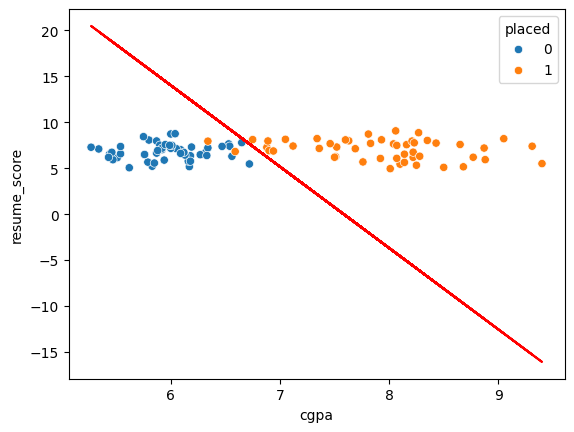

In [511]:
plt.plot(cgpa, resume_line, color="red")
sns.scatterplot(data=df, x="cgpa", y="resume_score", hue="placed")
plt.savefig('perceptron trick algorithm boundary.png')
plt.show()